In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

import plotly.graph_objects as go

In [8]:
node_pos_init = np.loadtxt('node_pos_init.csv', delimiter=',', dtype=float)
node_pos_final = np.loadtxt('node_pos_final.csv', delimiter=',', dtype=float)
ele_np = np.loadtxt('ele_np.csv', delimiter=',', dtype=int)

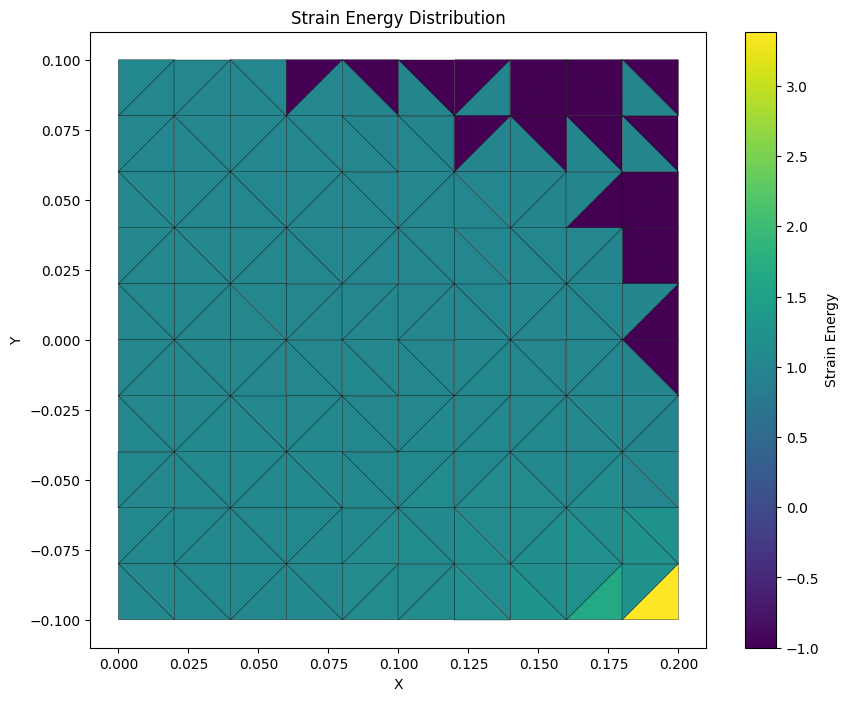

[[ 11.          23.          22.           1.05349505]
 [ 23.          11.          12.           1.04138875]
 [ 11.           1.          12.           1.03283788]
 [  1.          11.           0.           1.05828803]
 [ 99.         111.         110.           1.04339862]
 [111.          99.         100.           1.01434744]
 [ 47.          48.          58.           1.03815206]
 [ 48.          59.          58.           1.02863506]
 [ 48.          36.          37.           1.05281227]
 [ 36.          48.          47.           1.03767167]
 [ 59.          70.          58.           1.03439653]
 [ 70.          69.          58.           1.02361137]
 [ 80.          70.          81.           1.0188103 ]
 [ 70.          80.          69.           1.02124748]
 [ 86.          76.          87.          -0.99393978]
 [ 76.          86.          75.          -0.99868965]
 [ 34.          44.          33.           1.04209596]
 [ 44.          34.          45.           1.03367469]
 [ 34.    

In [17]:
def compute_deformation_gradient(node_pos_init, node_pos_final, ele_np):
    deformation_gradients = []
    for tri in ele_np:
        pos_init = node_pos_init[tri]
        pos_final = node_pos_final[tri]
        X = np.column_stack((pos_init[1] - pos_init[0], pos_init[2] - pos_init[0]))
        x = np.column_stack((pos_final[1] - pos_final[0], pos_final[2] - pos_final[0]))
        F = x @ np.linalg.inv(X)
        deformation_gradients.append(F)
    return np.array(deformation_gradients)

def compute_strain_energy(deformation_gradients):
    strain_energies = []
    for F in deformation_gradients:
        U, S, Vt = np.linalg.svd(F)
        epsilon = S - np.eye(2)
        if np.trace(epsilon) > 0:
            strain_energy = 0.5 * np.sum(epsilon**2)
        else:
            strain_energy = - 0.5 * np.sum(epsilon**2)
        strain_energies.append(strain_energy)
    return np.array(strain_energies)

# 计算变形梯度
deformation_gradients = compute_deformation_gradient(node_pos_init, node_pos_final, ele_np)

# 计算应变能
strain_energies = compute_strain_energy(deformation_gradients)

# Create a triangulation object
triang = tri.Triangulation(node_pos_init[:, 0], node_pos_init[:, 1], ele_np)

# Plot the triangulation with strain energies as color
plt.figure(figsize=(10, 8))
plt.tripcolor(triang, facecolors=strain_energies, edgecolors='k', cmap='viridis')
plt.colorbar(label='Strain Energy')
plt.title('Strain Energy Distribution')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().set_aspect('equal')
plt.show()

strain_energy_with_elements = np.column_stack((ele_np, strain_energies))
print(strain_energy_with_elements)